# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [ ]:
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from warnings import filterwarnings
filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import datetime
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.linear_model import Lasso
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge

from sklearn.metrics import mean_squared_error


In [ ]:
df = pd.read_csv('data/vehicles.csv')
df.head()
df.info()
df.describe()
df.sample(10)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 389559 entries, 0 to 389558
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            389559 non-null  int64  
 1   region        389558 non-null  object 
 2   price         389558 non-null  float64
 3   year          388453 non-null  float64
 4   manufacturer  373139 non-null  object 
 5   model         384643 non-null  object 
 6   condition     233652 non-null  object 
 7   cylinders     227662 non-null  object 
 8   fuel          386970 non-null  object 
 9   odometer      385698 non-null  float64
 10  title_status  382633 non-null  object 
 11  transmission  387266 non-null  object 
 12  VIN           239972 non-null  object 
 13  drive         268102 non-null  object 
 14  size          111495 non-null  object 
 15  type          303511 non-null  object 
 16  paint_color   271310 non-null  object 
 17  state         389558 non-null  object 
dtypes: f

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
353831,7310314031,jackson,31990.0,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,16594.0,clean,other,7JR102FK7LG060315,fwd,NaN,sedan,NaN,tn
383472,7311416286,tyler / east TX,34295.0,2018.0,ford,expedition,NaN,NaN,gas,54890.0,clean,automatic,1FMJU1HT2JEA13183,fwd,NaN,SUV,black,tx
41409,7316467079,orange county,9000.0,2002.0,toyota,sequoia limited,excellent,8 cylinders,gas,221000.0,clean,automatic,NaN,4wd,full-size,SUV,white,ca
223279,7312260869,st joseph,13000.0,1979.0,chevrolet,camaro,excellent,8 cylinders,gas,50000.0,clean,automatic,NaN,rwd,NaN,coupe,blue,mo
230448,7311557688,asheville,17499.0,2017.0,toyota,rav4,excellent,4 cylinders,gas,92335.0,clean,automatic,2T3BFREV2HW618153,NaN,NaN,NaN,black,nc
70235,7315991507,yuba-sutter,12000.0,2018.0,kia,forte,NaN,4 cylinders,gas,90039.0,clean,automatic,3KPFL4A75JE172330,fwd,NaN,sedan,brown,ca
96153,7306868581,ft myers / SW florida,43888.0,2018.0,ford,f-150,NaN,NaN,gas,68858.0,clean,automatic,1FTEW1EG3JFA27675,4wd,NaN,pickup,black,fl
70860,7311000461,yuba-sutter,9995.0,2002.0,ford,f150 4x4,NaN,NaN,gas,218252.0,clean,automatic,1FTRW08L02KB94184,4wd,NaN,NaN,NaN,ca
285463,7311358515,new hampshire,99.0,2020.0,nissan,versa,NaN,NaN,gas,21849.0,clean,automatic,3N1CN8EV9LL810691,fwd,full-size,sedan,blue,nh
106934,7311873027,orlando,8500.0,2007.0,chevrolet,silverado,good,8 cylinders,gas,270000.0,clean,automatic,NaN,rwd,full-size,pickup,blue,fl


manufacturer
ford               70985
chevrolet          55064
toyota             34202
honda              21269
nissan             19067
jeep               19014
ram                18342
gmc                16785
bmw                14699
dodge              13707
mercedes-benz      11817
hyundai            10338
subaru              9495
volkswagen          9345
kia                 8457
lexus               8200
audi                7573
cadillac            6953
chrysler            6031
acura               5978
buick               5501
mazda               5427
infiniti            4802
lincoln             4220
volvo               3374
mitsubishi          3292
mini                2376
pontiac             2288
rover               2113
jaguar              1946
porsche             1384
mercury             1184
saturn              1090
alfa-romeo           897
tesla                868
fiat                 792
harley-davidson      153
ferrari               95
datsun                63
aston-martin

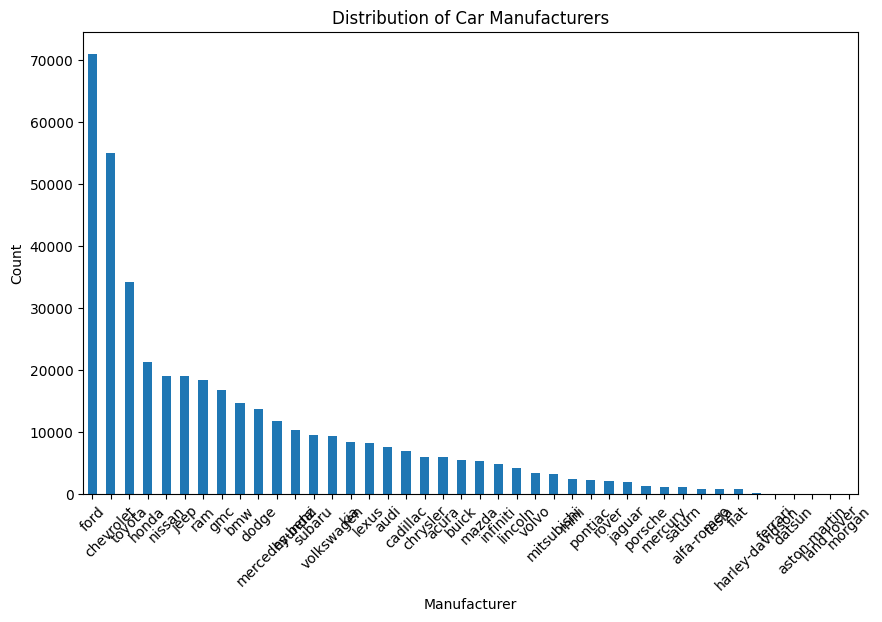

In [ ]:
manufacturer_counts = df['manufacturer'].value_counts()
print(manufacturer_counts)

plt.figure(figsize=(10, 6))
manufacturer_counts.plot(kind='bar', rot=45)
plt.xlabel("Manufacturer")
plt.ylabel("Count")
plt.title("Distribution of Car Manufacturers")
plt.show()

condition
good         121456
excellent    101467
like new      21178
fair           6769
new            1305
salvage         601
Name: count, dtype: int64


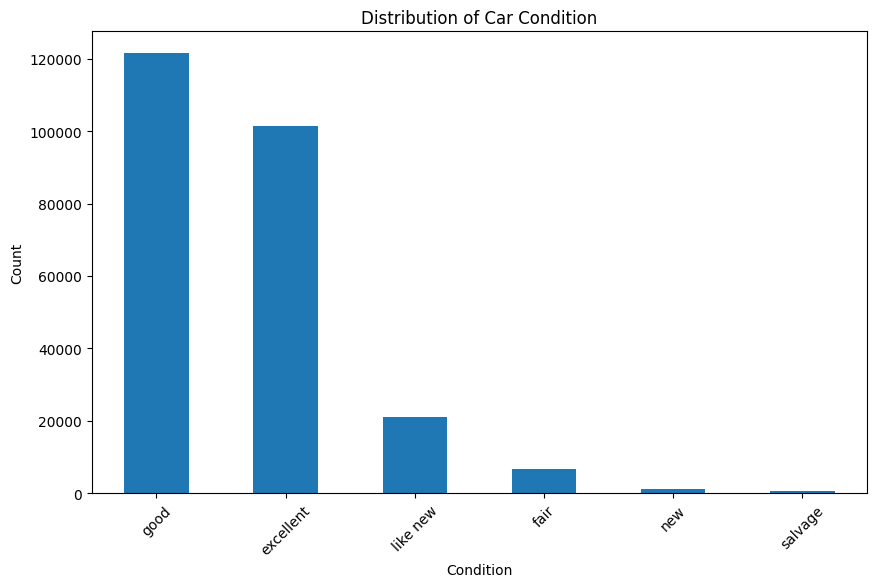

In [ ]:
condition_counts = df['condition'].value_counts()
print(condition_counts)
plt.figure(figsize=(10, 6))
condition_counts.plot(kind='bar', rot=45)
plt.xlabel("Condition")
plt.ylabel("Count")
plt.title("Distribution of Car Condition")
plt.show()


In [ ]:
missing_percentages = (df.isnull().sum() / len(df)) * 100
print(missing_percentages)

id               0.000000
region           0.000257
price            0.000257
year             0.283911
manufacturer     4.215023
model            1.261940
condition       40.021409
cylinders       41.559045
fuel             0.664598
odometer         0.991121
title_status     1.777908
transmission     0.588614
VIN             38.399062
drive           31.178076
size            71.379175
type            22.088567
paint_color     30.354580
state            0.000257
dtype: float64


KeyboardInterrupt: 

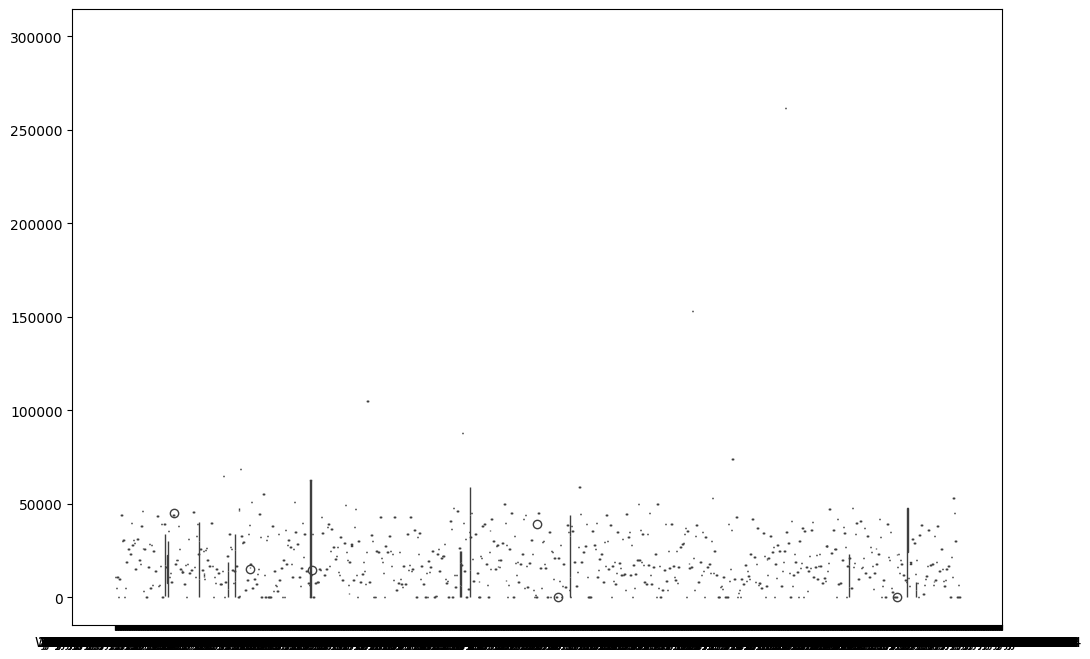

In [ ]:
df_sampled = df.sample(frac=0.1, random_state=42)

plt.figure(figsize=(12, 8))
sns.boxplot(x='VIN', y='price', data=df_sampled)
plt.title('Box Plot of Price vs. VIN')
plt.xlabel('VIN')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.show()



In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Violin plot for 'drive'
sns.violinplot(x='drive', y='price', data=df_sampled, hue=df_sampled['drive'].isnull(), ax=axes[0], palette='Set2')
axes[0].set_title('Violin Plot of Price vs. Drive')
axes[0].set_xlabel('Drive')
axes[0].set_ylabel('Price')

# Violin plot for 'size'
sns.violinplot(x='size', y='price', data=df_sampled, hue=df_sampled['size'].isnull(), ax=axes[1], palette='Set2')
axes[1].set_title('Violin Plot of Price vs. Size')
axes[1].set_xlabel('Size')
axes[1].set_ylabel('Price')

plt.tight_layout()
plt.show()

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

In [ ]:
# Drop rows/columns with a lot of missing data
threshold = 40

missing_percentages = (df.isnull().sum() / len(df)) * 100
columns_to_drop = missing_percentages[missing_percentages > threshold].index
df_cleaned = df.drop(columns_to_drop, axis=1)
df_cleaned = df_cleaned.dropna()
# will also drop VIN, dont know how to impute the data for vin
df_cleaned = df_cleaned.drop(['VIN'], axis=1)


print(df_cleaned.columns)

Index(['id', 'region', 'price', 'year', 'manufacturer', 'model', 'fuel',
       'odometer', 'title_status', 'transmission', 'drive', 'type',
       'paint_color', 'state'],
      dtype='object')


In [ ]:
# Impute missing values
numeric_features = ['year', 'odometer']
categorical_features = ['manufacturer', 'model', 'fuel', 'title_status', 'transmission', 'drive','type', 'paint_color']

# Using median for numerical features
numeric_imputer = SimpleImputer(strategy='median')
df_cleaned[numeric_features] = numeric_imputer.fit_transform(df_cleaned[numeric_features])

# Using Mode for Categorical features
categorical_imputer = SimpleImputer(strategy='most_frequent')
df_cleaned[categorical_features] = categorical_imputer.fit_transform(df_cleaned[categorical_features])

# # Adding age of the car, new feature
# current_year = datetime.datetime.now().year
# df_cleaned['car_age'] = current_year - df_cleaned['year']


Skewness: 52.56236537862379
The data is positively skewed (right-skewed).


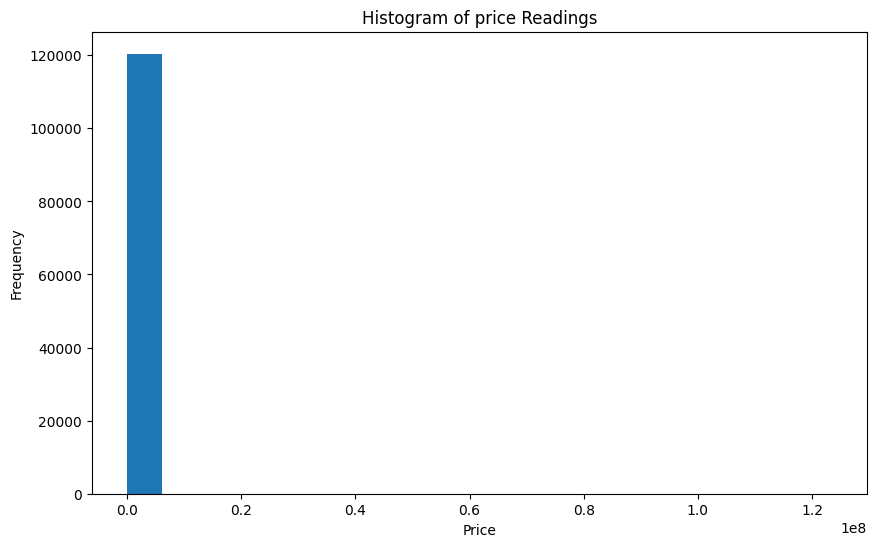

Skewness: 346.0635396535152
The data is positively skewed (right-skewed).


In [ ]:
# Skewness Calculation of numerical features

skewness_odometer = df_cleaned['odometer'].skew()
print("Skewness:", skewness_odometer)

# Interpretation
if skewness_odometer > 0:
    print("The data is positively skewed (right-skewed).")
elif skewness_odometer < 0:
    print("The data is negatively skewed (left-skewed).")
else:
    print("The data is approximately symmetric.")

plt.figure(figsize=(10, 6))
plt.hist(df_cleaned['price'], bins=20)  # Adjust the number of bins as needed
plt.title('Histogram of price Readings')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

skewness_price = df_cleaned['price'].skew()
print("Skewness:", skewness_price)
# Interpretation
if skewness_price > 0:
    print("The data is positively skewed (right-skewed).")
elif skewness_price < 0:
    print("The data is negatively skewed (left-skewed).")
else:
    print("The data is approximately symmetric.")

In [ ]:
# Price is highly skewed, so will log transform it.
print(len(df_cleaned))
X = df_cleaned.drop('price', axis=1)
y = df_cleaned['price']



120416


In [20]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features ),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])




### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [ ]:

# Create the pipeline with Lasso Regression
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Preprocessing steps
    ('lasso', Lasso())  # Lasso regression model
])


# Perform k-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold cross-validation
scores = cross_val_score(lasso_pipeline, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')

# Print the cross-validation scores
print("Cross-validation scores:", -scores)  # Negate the scores to get positive MSE values
print("Average MSE:", -scores.mean())

# Define parameter grid for GridSearchCV (tune alpha)
lasso_param_grid = {
    'lasso__alpha': [0.001, 0.01, 0.1, 1, 10]  # Explore different alpha values
}

# Create GridSearchCV object
lasso_grid_search = GridSearchCV(lasso_pipeline, lasso_param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit the model
lasso_grid_search.fit(X_train, y_train)
feature_names = preprocessor.get_feature_names_out()


# Get the best alpha value
best_alpha = lasso_grid_search.best_params_['lasso__alpha']
print("Best alpha:", best_alpha)

# Make predictions
lasso_predictions = lasso_grid_search.predict(X_test)

# Evaluate the model
lasso_mse = mean_squared_error(y_test, lasso_predictions)
lasso_r2 = r2_score(y_test, lasso_predictions)

best_lasso_model = lasso_grid_search.best_estimator_

# Get the Lasso coefficients
lasso_coef = best_lasso_model.named_steps['lasso'].coef_

# Create a DataFrame to store the coefficients and feature names
lasso_coef_df = pd.DataFrame({'feature': feature_names, 'coef': lasso_coef})

# Sort the DataFrame by absolute coefficient value in descending order
lasso_coef_df['abs_coef'] = np.abs(lasso_coef_df['coef'])
lasso_coef_df = lasso_coef_df.sort_values('abs_coef', ascending=False)

# Print the top contributing features for Lasso
print("Top Contributing Features for Lasso:")
print(lasso_coef_df.head(10))  # Print the top 10 features

print("Lasso MSE:", lasso_mse)
print("Lasso R-squared:", lasso_r2)


Cross-validation scores: [1.49337466e+08 1.24795272e+08 9.27094958e+07 9.57094601e+07
 9.45975989e+07]
Average MSE: 111429858.56249166


In [ ]:
# Create the pipeline with Ridge Regression
ridge_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('ridge', Ridge())])
ridge_pipeline.fit(X_train, y_train)
feature_names = preprocessor.get_feature_names_out()


# Perform k-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold cross-validation
scores = cross_val_score(ridge_pipeline, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')

# Print the cross-validation scores
print("Cross-validation scores:", -scores)  # Negate the scores to get positive MSE values
print("Average MSE:", -scores.mean())

# Define parameter grid for GridSearchCV (tune alpha)
ridge_param_grid = {
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 10]  # Explore different alpha values
}

# Create GridSearchCV object
ridge_grid_search = GridSearchCV(ridge_pipeline, ridge_param_grid, cv=5, scoring='neg_mean_squared_error')

# Split data into training and testing sets

# Fit the model with GridSearchCV
ridge_grid_search.fit(X_train, y_train)


# Get the best alpha value
best_alpha = ridge_grid_search.best_params_['ridge__alpha']
print("Best alpha:", best_alpha)

# Make predictions using the best model
ridge_predictions = ridge_grid_search.predict(X_test)

# Evaluate the model
ridge_mse = mean_squared_error(y_test, ridge_predictions)
ridge_r2 = r2_score(y_test, ridge_predictions)

print("Ridge MSE:", ridge_mse)
print("Ridge R-squared:", ridge_r2)

# Get the Ridge coefficients
best_ridge_model = ridge_grid_search.best_estimator_

ridge_coef = best_ridge_model.named_steps['ridge'].coef_

# Create a DataFrame to store the coefficients and feature names
ridge_coef_df = pd.DataFrame({'feature': feature_names, 'coef': ridge_coef})

# Sort the DataFrame by absolute coefficient value in descending order
ridge_coef_df['abs_coef'] = np.abs(ridge_coef_df['coef'])
ridge_coef_df = ridge_coef_df.sort_values('abs_coef', ascending=False)

# Print the top contributing features for Ridge
print("\nTop Contributing Features for Ridge:")
print(ridge_coef_df.head(10))  # Print the top 10 features

Cross-validation scores: [80748103.70433308 79648200.97771847 84448696.09163415 79541312.19603302
 76916934.78907043]
Average MSE: 80260649.55175783
Best alpha: 0.1
Ridge MSE: 632875890533.9705
Ridge R-squared: 1.023446419767815e-05

Top Contributing Features for Ridge:
                                  feature           coef       abs_coef
6317                 cat__model_regal gse  253822.746007  253822.746007
8272                     cat__model_wagon  170918.105039  170918.105039
5319  cat__model_mercedes-maybach s-class  163493.148769  163493.148769
677                 cat__model_488 spider  129079.063430  129079.063430
676                    cat__model_488 gtb  118675.280423  118675.280423
1480             cat__model_benz sprinter  105715.592745  105715.592745
5591                       cat__model_nsx  102258.590079  102258.590079
1648    cat__model_california convertible -100888.158482  100888.158482
6699                     cat__model_sedan  100523.455546  100523.455546
2252    c

In [ ]:
# Create the pipeline with Linear Regression
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('lr', LinearRegression())])

# Perform k-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold cross-validation
scores = cross_val_score(lr_pipeline, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')

# Print the cross-validation scores
print("Cross-validation scores:", -scores)  # Negate the scores to get positive MSE values
print("Average MSE:", -scores.mean())

# Fit the model
lr_pipeline.fit(X_train, y_train)

# Make predictions
lr_predictions = lr_pipeline.predict(X_test)

# Evaluate the model
lr_mse = mean_squared_error(y_test, lr_predictions)
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression MSE:", lr_mse)
print("Linear Regression R-squared:", lr_r2)

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [ ]:

# Assuming you have your fitted Lasso and Ridge models in 'lasso_grid_search' and 'ridge_grid_search' respectively
# and your preprocessor object is named 'preprocessor'

# Get the best Lasso and Ridge models from the grid search
best_lasso_model = lasso_grid_search.best_estimator_
best_ridge_model = ridge_grid_search.best_estimator_

# Get the feature names after one-hot encoding
feature_names = preprocessor.get_feature_names_out()

# 1. Lasso Coefficients

# Get the Lasso coefficients
lasso_coef = best_lasso_model.named_steps['lasso'].coef_

# Create a DataFrame to store the coefficients and feature names
lasso_coef_df = pd.DataFrame({'feature': feature_names, 'coef': lasso_coef})

# Sort the DataFrame by absolute coefficient value in descending order
lasso_coef_df['abs_coef'] = np.abs(lasso_coef_df['coef'])
lasso_coef_df = lasso_coef_df.sort_values('abs_coef', ascending=False)

# Print the top contributing features for Lasso
print("Top Contributing Features for Lasso:")
print(lasso_coef_df.head(10))  # Print the top 10 features


# 2. Ridge Coefficients

# Get the Ridge coefficients
ridge_coef = best_ridge_model.named_steps['ridge'].coef_

# Create a DataFrame to store the coefficients and feature names
ridge_coef_df = pd.DataFrame({'feature': feature_names, 'coef': ridge_coef})

# Sort the DataFrame by absolute coefficient value in descending order
ridge_coef_df['abs_coef'] = np.abs(ridge_coef_df['coef'])
ridge_coef_df = ridge_coef_df.sort_values('abs_coef', ascending=False)

# Print the top contributing features for Ridge
print("\nTop Contributing Features for Ridge:")
print(ridge_coef_df.head(10))  # Print the top 10 features

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.